# Phase 2 : Signal Analysis

## Objective

Investigate how machine condition is represented in the frequency domain.

Initial comparison:
- Fan
- id_00
- 0 dB
- Normal vs Abnormal

The first experiment uses the FFT to compare the frequency spectra of
normal and abnormal recordings.

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [84]:
normal_path = 'C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/normal/00000000.wav'
abnormal_path = 'C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/abnormal/00000000.wav'

normal_y, sr = librosa.load(normal_path, sr = None)
abnormal_y, _ = librosa.load(abnormal_path, sr = None)

print('Sampling rate: ', sr)
print('Samples: ', len(normal_y))

N = len(normal_y)
normal_fft = np.fft.rfft(normal_y)
abnormal_fft = np.fft.rfft(abnormal_y)

frequencies = np.fft.rfftfreq(N, d = 1/sr)

normal_magnitude = np.abs(normal_fft)/N
abnormal_magnitude = np.abs(abnormal_fft)/N

Sampling rate:  16000
Samples:  160000


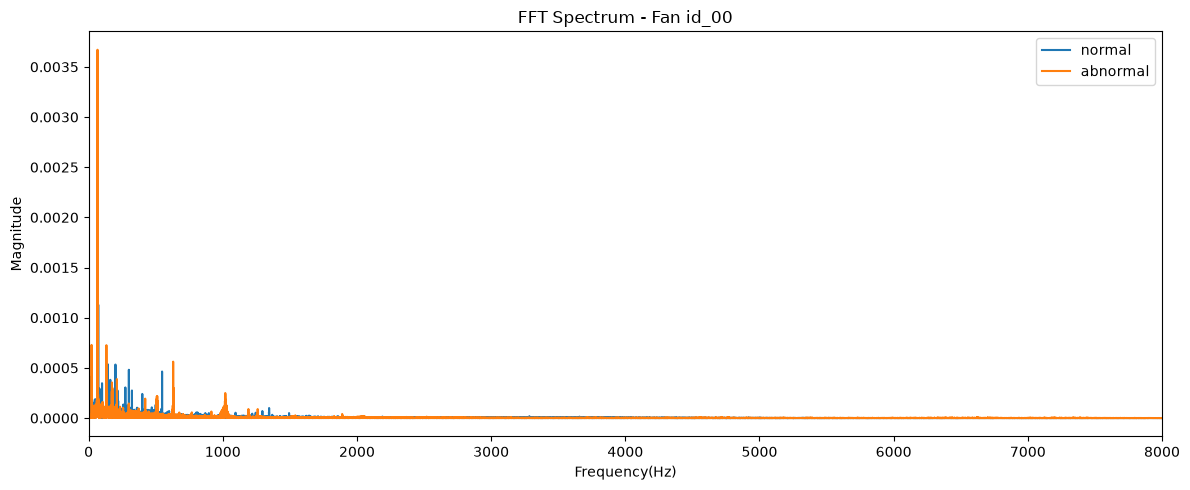

In [85]:
plt.figure(figsize=(12,5))

plt.plot(frequencies, normal_magnitude, label = 'normal')
plt.plot(frequencies, abnormal_magnitude, label = 'abnormal')

plt.xlabel('Frequency(Hz)')
plt.ylabel('Magnitude')
plt.title('FFT Spectrum - Fan id_00')
plt.legend()

plt.xlim(0, 8000)
plt.tight_layout()
plt.show()

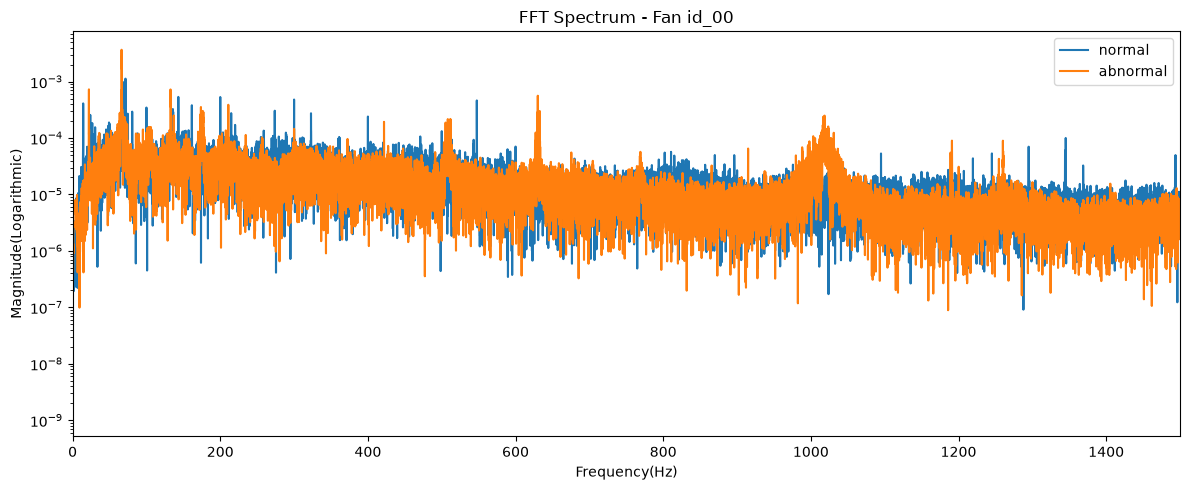

Strongest normal frequencies: 
71.6 Hz -> 0.001129
67.8 Hz -> 0.000993
67.9 Hz -> 0.000971
68.0 Hz -> 0.000547
143.2 Hz -> 0.000536
200.0 Hz -> 0.000533
300.0 Hz -> 0.000481
547.5 Hz -> 0.000464
14.3 Hz -> 0.000411
67.6 Hz -> 0.000405

Strongest abnormal frequencies: 
66.3 Hz -> 0.003671
66.5 Hz -> 0.002784
66.2 Hz -> 0.001925
66.4 Hz -> 0.001690
66.6 Hz -> 0.001514
22.1 Hz -> 0.000729
132.6 Hz -> 0.000726
66.0 Hz -> 0.000711
133.0 Hz -> 0.000617
66.7 Hz -> 0.000580


In [86]:
plt.figure(figsize=(12,5))

plt.semilogy(frequencies, normal_magnitude, label = 'normal')
plt.semilogy(frequencies, abnormal_magnitude, label = 'abnormal')

plt.xlabel('Frequency(Hz)')
plt.ylabel('Magnitude(Logarithmic)')
plt.title('FFT Spectrum - Fan id_00')
plt.legend()

plt.xlim(0, 1500)
plt.tight_layout()
plt.show()

normal_indices = np.argsort(normal_magnitude[1:])[-10:]+1
abnormal_indices = np.argsort(abnormal_magnitude[1:])[-10:]+1

print('Strongest normal frequencies: ')
for i in normal_indices[::-1]:
    print(f'{frequencies[i]:.1f} Hz -> {normal_magnitude[i]:.6f}')

print('\nStrongest abnormal frequencies: ')
for i in abnormal_indices[::-1]:
    print(f'{frequencies[i]:.1f} Hz -> {abnormal_magnitude[i]:.6f}')

In [87]:
low_freq_mask = frequencies<=500

normal_energy = np.sum(normal_magnitude[low_freq_mask]**2)
abnormal_energy = np.sum(abnormal_magnitude[low_freq_mask]**2)

total_normal_energy = np.sum(normal_magnitude**2)
total_abnormal_energy = np.sum(abnormal_magnitude**2)

print('Normal low freq energy ratio: ',normal_energy/total_normal_energy)
print('Abnormal low freq energy ratio: ',abnormal_energy/total_abnormal_energy)

Normal low freq energy ratio:  0.8809145
Abnormal low freq energy ratio:  0.90084666


### Observation

For the inspected normal and abnormal recordings, most of the
FFT-derived spectral energy is concentrated below 500 Hz. The abnormal
recording also shows substantially stronger spectral components around
66 Hz.

The FFT does not preserve when these frequency components occur, which
motivates time-frequency analysis using the STFT.

## Short-Time Fourier Transform

The STFT divides the audio signal into overlapping short-time frames
and computes a Fourier transform for each frame. This provides a
time-frequency representation of the machine sound.

In [88]:
n_fft = 1024
hop_length = 256

normal_stft = librosa.stft(normal_y, n_fft = n_fft, hop_length = hop_length)
abnormal_stft = librosa.stft(abnormal_y, n_fft = n_fft, hop_length = hop_length)

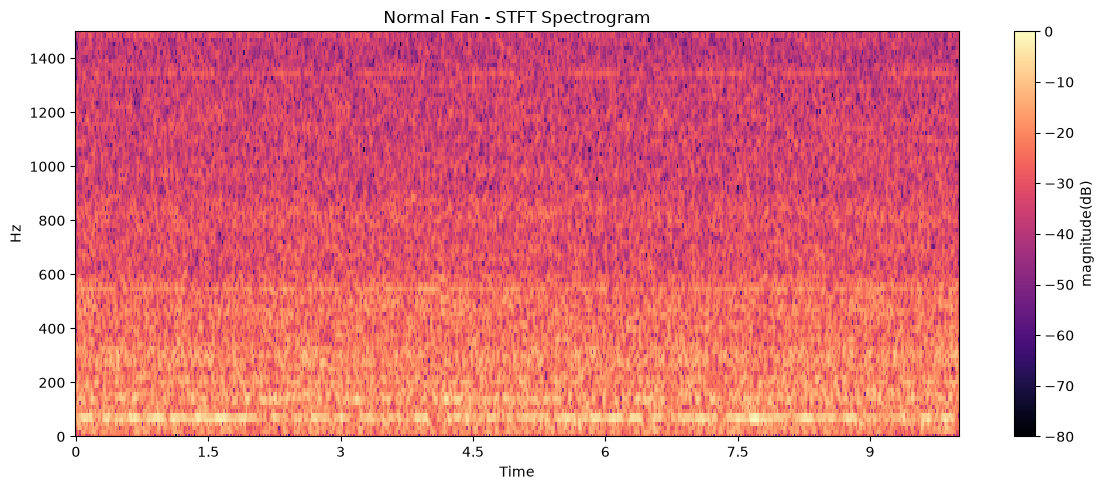

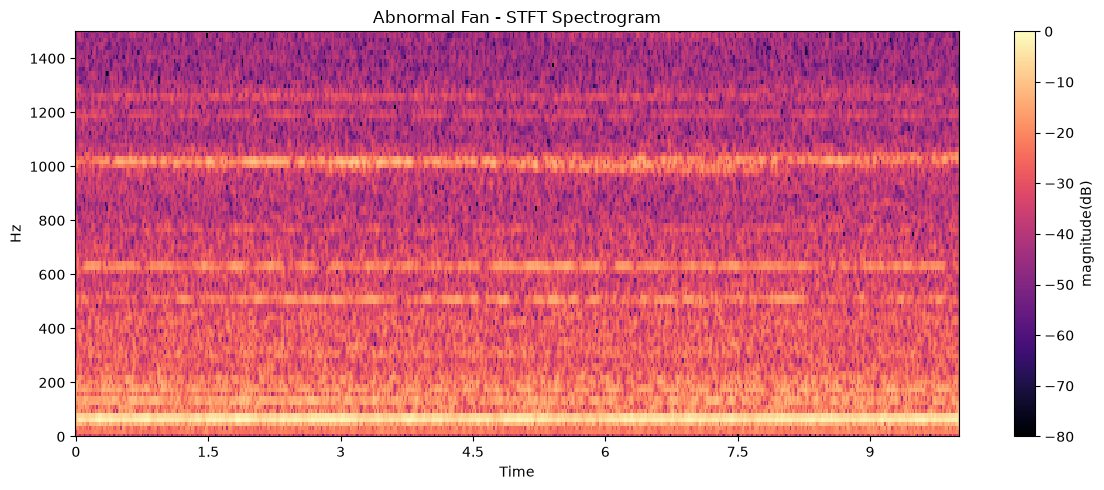

In [89]:
normal_stft_magnitude = np.abs(normal_stft)
abnormal_stft_magnitude = np.abs(abnormal_stft)

normal_db = librosa.amplitude_to_db(normal_stft_magnitude, ref = np.max)
abnormal_db = librosa.amplitude_to_db(abnormal_stft_magnitude, ref = np.max)

plt.figure(figsize = (12,5))
librosa.display.specshow(
    normal_db,
    sr = sr,
    hop_length=hop_length,
    x_axis = 'time',
    y_axis = 'hz'
)

plt.colorbar(label = 'magnitude(dB)')
plt.title('Normal Fan - STFT Spectrogram')
plt.ylim(0,1500)
plt.tight_layout()
plt.show()

plt.figure(figsize = (12,5))
librosa.display.specshow(
    abnormal_db,
    sr = sr,
    hop_length=hop_length,
    x_axis = 'time',
    y_axis = 'hz'
)

plt.colorbar(label = 'magnitude(dB)')
plt.title('Abnormal Fan - STFT Spectrogram')
plt.ylim(0,1500)
plt.tight_layout()
plt.show()

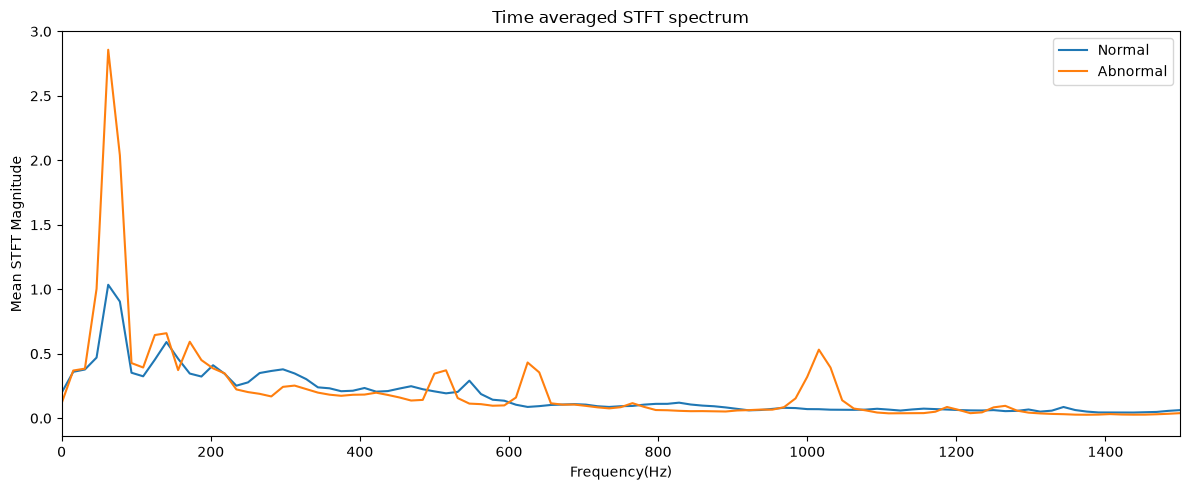

In [90]:
normal_mean_spectrum = normal_stft_magnitude.mean(axis = 1)
abnormal_mean_spectrum = abnormal_stft_magnitude.mean(axis = 1)

stft_frequencies = librosa.fft_frequencies(
    sr = sr,
    n_fft = n_fft
)

plt.figure(figsize=(12,5))
plt.plot(stft_frequencies, normal_mean_spectrum, label = 'Normal')
plt.plot(stft_frequencies, abnormal_mean_spectrum, label = 'Abnormal')
plt.xlabel('Frequency(Hz)')
plt.ylabel('Mean STFT Magnitude')
plt.title('Time averaged STFT spectrum')
plt.legend()
plt.xlim(0,1500)
plt.tight_layout()
plt.show()

In [91]:
normal_centroid = librosa.feature.spectral_centroid(
    y = normal_y,
    sr = sr,
    n_fft = n_fft,
    hop_length=hop_length
).mean()

abnormal_centroid = librosa.feature.spectral_centroid(
    y=abnormal_y,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length
).mean()

print('Normal spectral centroid: ',normal_centroid)
print('Abnormal spectral centroid: ',abnormal_centroid)

Normal spectral centroid:  996.4431028207957
Abnormal spectral centroid:  919.6526881607211


## Frequency-Domain Feature Extension

The signal analysis showed that abnormal recordings contain stronger
and more persistent low-frequency spectral components.

Three frequency-domain features are therefore evaluated:

- Spectral centroid
- Spectral bandwidth
- Low-frequency energy ratio below 500 Hz

These features will be extracted for all recordings and evaluated
against the existing time-domain baseline.

In [92]:
normal_bandwidth = librosa.feature.spectral_bandwidth(
    y = normal_y,
    sr = sr,
    n_fft = n_fft,
    hop_length=hop_length
).mean()

abnormal_bandwidth = librosa.feature.spectral_bandwidth(
    y=abnormal_y,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length
).mean()

print('Normal spectral bandwidth: ',normal_bandwidth)
print('Abnormal spectral bandwidth: ',abnormal_bandwidth)

Normal spectral bandwidth:  1326.7763282548142
Abnormal spectral bandwidth:  1500.787080014928


In [93]:
def extract_frequency_features(audio_path):
    y, sr = librosa.load(audio_path, sr = None)

    stft = librosa.stft(
        y,
        n_fft = 1024,
        hop_length=256
    )

    magnitude = np.abs(stft)

    centroid = librosa.feature.spectral_centroid(
        S=magnitude,
        sr=sr
    ).mean()

    bandwidth = librosa.feature.spectral_bandwidth(
        S = magnitude,
        sr=sr
    ).mean()

    frequencies = librosa.fft_frequencies(
        sr=sr,
        n_fft = 1024
    )

    low_freq_mask = frequencies<=500

    low_freq_energy = np.sum(magnitude[low_freq_mask]**2)
    total_energy = np.sum(magnitude**2)
    low_freq_ratio = low_freq_energy/total_energy

    return {'spectral centroid':centroid, 'spectral bandwidth':bandwidth, 'low freq energy ratio':low_freq_ratio}

In [94]:
normal_freq_features = extract_frequency_features('C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/normal/00000000.wav')
abnormal_freq_features = extract_frequency_features('C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/abnormal/00000000.wav')

records = [normal_freq_features, abnormal_freq_features]
freq_df = pd.DataFrame(records, index=['normal','abnormal'])
freq_df

,spectral centroid,spectral bandwidth,low freq energy ratio
normal,996.443103,1326.776328,0.884861
abnormal,919.652688,1500.787080,0.908680


In [95]:
frequency_records = []

data_root = Path('C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00')

for label in ['normal','abnormal']:
    folder = data_root/label

    for audio_file in sorted(folder.glob('*.wav')):
        features = extract_frequency_features(audio_file)

        frequency_records.append({
            'file name':audio_file.name,
            'label':label,
            'target': 0 if label=='normal' else 1,
            **features}
        )

freq_df = pd.DataFrame(frequency_records)
print('Number of records: ',len(freq_df))
freq_df.head()

Number of records:  160


,file name,label,target,spectral centroid,spectral bandwidth,low freq energy ratio
0,00000000.wav,normal,0,996.443103,1326.776328,0.884861
1,00000001.wav,normal,0,1125.339432,1454.302695,0.881871
2,00000002.wav,normal,0,1336.266853,1616.754632,0.770581
3,00000003.wav,normal,0,1359.109303,1793.817895,0.652875
4,00000004.wav,normal,0,1177.623867,1450.228805,0.812017


In [96]:
frequency_features = ['spectral centroid','spectral bandwidth','low freq energy ratio']
freq_df.groupby('label')[frequency_features].mean()

,spectral centroid,spectral bandwidth,low freq energy ratio
label,,,
abnormal,933.747925,1398.724228,0.937134
normal,1219.073864,1560.354895,0.801736


In [97]:
freq_corr = freq_df[frequency_features].corr()
freq_corr

,spectral centroid,spectral bandwidth,low freq energy ratio
spectral centroid,1.000000,0.909481,-0.723501
spectral bandwidth,0.909481,1.000000,-0.648048
low freq energy ratio,-0.723501,-0.648048,1.000000


In [98]:
X_freq = freq_df[frequency_features]
y_freq = freq_df['target']

X_freq_train, X_freq_test, y_freq_train, y_freq_test = train_test_split(
    X_freq,
    y_freq,
    test_size = 0.2,
    random_state=42,
    stratify=y_freq
)

print('Training samples: ',len(X_freq_train))
print('Test samples: ',len(X_freq_test))

freq_model = Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',LogisticRegression())
])

freq_model.fit(X_freq_train, y_freq_train)

y_freq_pred = freq_model.predict(X_freq_test)

Training samples:  128
Test samples:  32


In [99]:
freq_accuracy = accuracy_score(y_freq_test, y_freq_pred)
print('Freq only accuracy: ',freq_accuracy)
print()
print(confusion_matrix(y_freq_test,y_freq_pred))

Freq only accuracy:  0.84375

[[13  3]
 [ 2 14]]


In [100]:
from acoustic_fault.features import extract_features

time_records = []

for label in ['normal','abnormal']:
    folder = data_root/label

    for audio_file in sorted(folder.glob('*.wav')):
        features = extract_features(audio_file)

        time_records.append({
            'file name':audio_file.name,
            'label':label,
            'target':0 if label == 'normal' else 1,
            **features
        })

time_df = pd.DataFrame(time_records)

In [101]:
combined_df = pd.concat(
    [
        time_df[['file name','label','target','RMS','ZCR','Peak']],
        freq_df[['spectral centroid','spectral bandwidth','low freq energy ratio']]
    ],axis = 1
)

combined_features = ['RMS','ZCR','Peak','spectral centroid','spectral bandwidth','low freq energy ratio']

X_combined = combined_df[combined_features]
y_combined = combined_df['target']

X_comb_train, X_comb_test, y_comb_train, y_comb_test = train_test_split(
    X_combined,
    y_combined,
    test_size=0.2,
    random_state=42,
    stratify=y_combined
)

combined_model = Pipeline([
    ('scaler',StandardScaler()),('classifier',LogisticRegression())
])

combined_model.fit(X_comb_train, y_comb_train)
y_comb_pred = combined_model.predict(X_comb_test)

In [102]:
combined_score = accuracy_score(y_comb_test, y_comb_pred)

print('Combined accuracy: ', combined_score)
print()
print(confusion_matrix(y_comb_test, y_comb_pred))

Combined accuracy:  1.0

[[16  0]
 [ 0 16]]


## Phase 2 : Results

### Signal analysis

FFT analysis showed that the inspected recordings contain strong
low-frequency spectral components, with the abnormal recording showing
substantially stronger components around approximately 66 Hz.

STFT analysis revealed persistent frequency bands in the abnormal
recording that were less pronounced in the normal recording.

### Feature comparison

Three frequency-domain features were evaluated:

- Spectral centroid
- Spectral bandwidth
- Low-frequency energy ratio below 500 Hz

Using standardized Logistic Regression on the same 80/20 stratified
evaluation setup:

| Representation | Test accuracy |
|---|---:|
| Time-domain | 100% |
| Frequency-domain | 84.375% |
| Combined | 100% |

### Conclusion

The frequency-domain features provide useful information about the
difference between normal and abnormal machine operation, but they do
not improve classification performance beyond the time-domain baseline
on this controlled subset.

This result is limited to fan id_00 under the 0 dB condition and does
not establish generalization across machine instances or changed
conditions.